In [1]:
import scanpy as sc
import scvelo as scv
import matplotlib.pyplot as plt

In [2]:
print(scv.__version__)

0.3.3


In [20]:
N4 = sc.read("Bflo.N4_glia.velo_added.h5ad", cache=True)
T1 = sc.read("Bflo.T1_glia.velo_added.h5ad", cache=True)

Only considering the two last: ['.velo_added', '.h5ad'].
Only considering the two last: ['.velo_added', '.h5ad'].
Only considering the two last: ['.velo_added', '.h5ad'].
Only considering the two last: ['.velo_added', '.h5ad'].


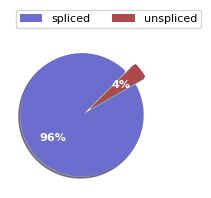

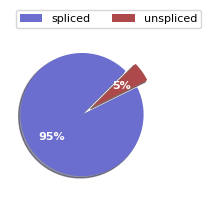

In [21]:
scv.pl.proportions(N4)
scv.pl.proportions(T1)

In [22]:
def data_pre(adata):
    scv.pp.filter_genes(adata, min_shared_counts=3)
    scv.pp.normalize_per_cell(adata)
    scv.pp.filter_genes_dispersion(adata, n_top_genes=3000)
    scv.pp.log1p(adata)
    scv.pp.moments(adata, n_pcs=50, n_neighbors=30)

data_pre(N4)
data_pre(T1)

Filtered out 16369 genes that are detected 3 counts (shared).
Normalized count data: X, spliced, unspliced.
Extracted 3000 highly variable genes.


/tmp/ipykernel_127683/800502470.py:5: DeprecationWarning: `log1p` is deprecated since scVelo v0.3.0 and will be removed in a future version. Please use `log1p` from `scanpy.pp` instead.
  scv.pp.log1p(adata)
/tmp/ipykernel_127683/800502470.py:6: DeprecationWarning: Automatic neighbor calculation is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors first with Scanpy.
  scv.pp.moments(adata, n_pcs=50, n_neighbors=30)
/home/zoo/ball6395/software/miniconda3/envs/trajectory/lib/python3.13/scvelo/preprocessing/moments.py:71: DeprecationWarning: `neighbors` is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors with Scanpy.
  neighbors(


computing neighbors
    finished (0:00:00) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:01) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
Filtered out 15603 genes that are detected 3 counts (shared).
Normalized count data: X, spliced, unspliced.
Extracted 3000 highly variable genes.
computing neighbors


/tmp/ipykernel_127683/800502470.py:5: DeprecationWarning: `log1p` is deprecated since scVelo v0.3.0 and will be removed in a future version. Please use `log1p` from `scanpy.pp` instead.
  scv.pp.log1p(adata)
/tmp/ipykernel_127683/800502470.py:6: DeprecationWarning: Automatic neighbor calculation is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors first with Scanpy.
  scv.pp.moments(adata, n_pcs=50, n_neighbors=30)
/home/zoo/ball6395/software/miniconda3/envs/trajectory/lib/python3.13/scvelo/preprocessing/moments.py:71: DeprecationWarning: `neighbors` is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors with Scanpy.
  neighbors(


    finished (0:00:00) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


In [23]:
scv.tl.recover_dynamics(N4, n_jobs=20)
scv.tl.recover_dynamics(T1, n_jobs=20)

recovering dynamics (using 20/72 cores)


  0%|          | 0/766 [00:00<?, ?gene/s]

/home/zoo/ball6395/software/miniconda3/envs/trajectory/lib/python3.13/multiprocessing/popen_fork.py:67: DeprecationWarning: This process (pid=127683) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


    finished (0:01:03) --> added 
    'fit_pars', fitted parameters for splicing dynamics (adata.var)
recovering dynamics (using 20/72 cores)


  0%|          | 0/1603 [00:00<?, ?gene/s]

/home/zoo/ball6395/software/miniconda3/envs/trajectory/lib/python3.13/multiprocessing/popen_fork.py:67: DeprecationWarning: This process (pid=127683) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


    finished (0:02:14) --> added 
    'fit_pars', fitted parameters for splicing dynamics (adata.var)


In [24]:
scv.tl.velocity(N4, mode='dynamical')
scv.tl.velocity(T1, mode='dynamical')

computing velocities
    finished (0:00:04) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocities
    finished (0:00:13) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)


In [25]:
scv.tl.velocity_graph(N4)
scv.tl.velocity_graph(T1)

computing velocity graph (using 1/72 cores)


  0%|          | 0/4214 [00:00<?, ?cells/s]

/home/zoo/ball6395/software/miniconda3/envs/trajectory/lib/python3.13/multiprocessing/popen_fork.py:67: DeprecationWarning: This process (pid=127683) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


    finished (0:00:13) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity graph (using 1/72 cores)


  0%|          | 0/4828 [00:00<?, ?cells/s]

/home/zoo/ball6395/software/miniconda3/envs/trajectory/lib/python3.13/multiprocessing/popen_fork.py:67: DeprecationWarning: This process (pid=127683) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


    finished (0:00:40) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)


In [46]:
scv.pl.velocity_embedding_stream(N4, basis='umap', color='celltype', show=False, save = 'N4.svg')
scv.pl.velocity_embedding_stream(T1, basis='umap', color='celltype', show=False, save = 'T1.svg')

/home/zoo/ball6395/software/miniconda3/envs/trajectory/lib/python3.13/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/zoo/ball6395/software/miniconda3/envs/trajectory/lib/python3.13/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/zoo/ball6395/software/miniconda3/envs/trajectory/lib/python3.13/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/zoo/ball6395/software/miniconda3/e

saving figure to file ./figures/scvelo_N4.svg


/home/zoo/ball6395/software/miniconda3/envs/trajectory/lib/python3.13/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/zoo/ball6395/software/miniconda3/envs/trajectory/lib/python3.13/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/zoo/ball6395/software/miniconda3/envs/trajectory/lib/python3.13/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/zoo/ball6395/software/miniconda3/e

saving figure to file ./figures/scvelo_T1.svg


<Axes: title={'center': 'celltype'}>

In [13]:
#scv.pl.velocity(N4, var_names = ["bf12-635"])
#scv.pl.velocity(T1, var_names = ['bf12-635'])

In [55]:
'bf12-633' in N4.var_names

False

/home/zoo/ball6395/software/miniconda3/envs/trajectory/lib/python3.13/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/zoo/ball6395/software/miniconda3/envs/trajectory/lib/python3.13/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/zoo/ball6395/software/miniconda3/envs/trajectory/lib/python3.13/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/zoo/ball6395/software/miniconda3/e

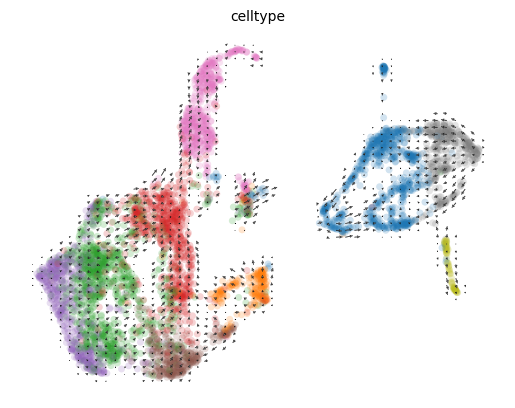

In [45]:
 scv.pl.velocity_embedding_grid(T1, basis='umap', color='celltype')

In [41]:

arr= np.asarray(T1.obsm['velocity_umap'])

np.isfinite(arr).all()

np.True_